# 최소비용문제
1. 복잡하게 얽힌 수많은 정점과 간선 중
2. "전체를 연결" 하는 가장 최소비용의 방법을 찾기
3. 단, 싸이클이 생기면 안된다.

- V개의 모든 정점이 연결되게 하려면, 최소 V-1개의 간선이 필요하다.
- 이때 최소인 V-1개의 간선만으로 연결된 트리가 신장 트리.
- 최소 신장 트리는 신장트리중 가중치의 합이 최소인 트리.
- 그게 최소신장트리를 다른말로 MST. 
- MST는 여러개이다.

- 그래프의 표현: 인접행렬과 인접리스트/보통은 인접리스트(가중치, 다음노드)
- MST의 두가지방법
  - 1. BFS처럼 정점에서 출발해서 "인접한 도드들 중 가중치가 가장 작은 것"을 고르자 => Prim 
    - 큐에서 꺼낼건데 가장 작은 것부터 먼저 꺼낸다. 최소힙(우선순위큐)
  - 2. 전체 간선들 보면서 "작은 것부터" 고르자 => Kruskal
    - 간선을 정렬하고 사이클이 없으면 선택.

## 크루스칼
- 모든 간선을 가중치에 따라 오름차순 정렬
- 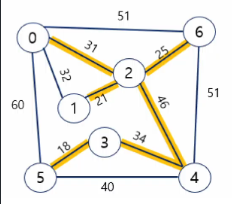

- 크루스칼은 모든 간선을 가중치에 따라 오름차순 정렬하고
- 간선을 선택할때마다 유니온을 이용해 합집합처리
- 간선의 양끝정점이 같은 집합이면 걔는 선택불가(선택하면 사이클)
- 이렇게 V-1개의 간선을 선택하면 

# 공부법
### 개념 => 나만의언어
### 그림 => 나만의그림
### 기본코드 => 안보고치기

- MST ( 최소신장트리 )
  - 신장트리: 무방향 그래프에서, 모든 V개의 정점이 싸이클없이 V-1개의 간선으로 연결된 트리
  - 최소신장트리: 신장트리에서 가중치의 합이 최소인 트리
- 그래프를 표현하는법:
  - 인접행렬, 인접리스트
  - 인접행렬: 2차원행렬로써, (i,j)가 의미하는건 i에서 j로의 간선이 존재하냐인데, 가중치가 존재하는 그래프에서는 그 자리에 가중치가 들어감. 무향이면, 대각선기준으로 대칭
  - 인접리스트: 1차원리스트인데(리스트안에 리스트가 있어서 2차원으로 불러야 하나 헷갈림) 각 인덱스마다 빈 리스트를 생성해둔다. 각 인덱스는 출발정점을 의미하고, 안에 들어갈 값은 그 출발정점으로부터 도착정점까지의 (가중치,도착정점)형태로 저장됨. 예를들어 1번정점에서 2번,4번 정점에 연결되어 있다면, 1번인덱스는 [(가중치,2),(가중치,4)] 형태의 리스트가 됨.즉, 인접리스트 안의 각 인덱스는 리스트이고, 그 리스트안에는 여러개의 튜플이 들어갈 수 있다. 유향그래프에서는 인접리스트안의 튜플의 개수가 곧 간선의 개수가 되겠지만, 무향그래프에서는 2배가 된다. 그럼.. 튜플의 개수 나누기 2하면 간선의 개수가 될 것 같다. 인접리스트 안의 각 인덱스리스트 안에 들어가있는 튜플들의 개수는 곧 그 시작정점(인덱스)에서 연결된 간선의 개수라고 볼 수 있다.
- Prim 알고리즘
  - MST의 한 종류로써 최소신장트리를 구하는 방법이다. MST라는 visited배열이 필요한데, 이것은 일차원리스트로써, 지금까지 연결된 정점들을 보여준다. MST에서는 지금까지 연결된 정점들과 연결되지 않은 정점들로 나뉘게 되고, 연결된 정점들이 모두 V개가 된다면, 즉, MST배열이 모두 True로 가득차게 된다면 최소신장트리를 완성했다고 볼 수 있다. 프림의 기본 원리는 하나의 정점으로부터 BFS처럼 나에게 연결된 간선들의 정보를 (가중치,도착정점)의 형태로 최소힙에 넣는다. 그리고 그 최소힙에서 하나를 pop해서 그 도착정점을 MST에 포함해주고(확정시켜주고) 그 도착정점으로부터 연결된 간선들의 정보를 또다시 최소힙에 넣는다. 이때, 도착정점이 MST에 이미 포함되어 있는놈은 넣지않는다(같은 간선을 선택하거나 싸이클을 만드는 것을 방지). 그리고 또 pop을 해서 MST에 확정시켜주고 그로부터 연결된 간선정보를 push 해주고를 반복한다. 이때, pop을 하고 MST에 확정시켜주기 전에, pop을 한녀석이 MST에 포함되어있는지를 확인하고 포함안되있을떄만 넣도록 해준다. ~~아니 이미 연결된 간선정보를 넣기전에 MST에 포함되있는지는 확인했지 않냐 할 수 있지만, 최소신장트리를 다 완성한 후에 힙에 남아있는 놈들도 계속 pop이 진행된다.이때, 걔네들은 MST에 다 포함된놈들이기에 아무 액션없이 pop만 되도록 해주기 위함이다.~~ 이 부분 수정하자면, 최소신장트리를 다 완성한 후에가 아니라 최소신장트리를 만드는과정에서 이미 visited인 놈이 가중치는 최소여서 pop되는 경우가 있으므로 그때를 걸러주기 위해서이다. 즉, 오히려 이게 필수이고, 힙에 넣기 전에 not visited 인 놈들만 넣는건 선택.
- 그림완료

## 아래는 종료조건을 V개의 노드를 선택한경우로 만듦

In [6]:
import sys
sys.stdin = open("mst_input.txt", "r")

# import heapq
from heapq import heappush, heappop 

# 특정 정점 기준으로 시작
# - 갈 수 있는 노드들 중 가중치가 가장 작은 노드부터 간다
# --> 작은 노드를 먼저 꺼내기 위해 우선순위큐(heapq)를 활용한다
def prim(start_node):
    pq = [(0, start_node)]     # (가중치, 노드) 형태로 시작점을 담은상태로 큐생성
    MST = [0] * V              # visited 와 동일하다 - MST 생성
    min_weight = 0               # 최소 비용 변수 생성
    cnt = 0                     # 현재까지 선택된 노드수
    # while문 시작
    while cnt < V:
        # 힙팝을 해서 현가중치,현노드
        weight, node = heappop(pq)
        # 이미 방문한 노드라면 continue
        if MST[node]:
            continue
        
        # 현재 노드에서 해야할 액션 => MST포함체크와 누적합추가
            # queue 에서 pop 될 때 MST 에 포함되는 게 확정!
        MST[node] = 1
            # 누적합 추가
        min_weight += weight
        cnt += 1


        # 연결된 노드를 탐색(탐색에서 할 액션은 큐에 넣는 것 한가지뿐)
        for next_weight, next_node in graph[node]:        
            # 이미 방문했으면 continue
            if MST[next_node]:
                continue
            # 탐색노드들을 푸시
            heappush(pq, (next_weight, next_node))
    # 최소비용을 리턴하기
    return min_weight



# V,E 입력받기
V, E = map(int, sys.stdin.readline().split())
# 인접 리스트
graph = [[] for _ in range(V)]
# E줄 입력받아 인접리스트 완성하기(무향)
for _ in range(E):
    start, end, weight = map(int, sys.stdin.readline().split())    
    graph[start].append((weight, end))
    graph[end].append((weight, start))

# 출발 정점과 함께 시작
# 출발 정점을 바꾸어도, 최소비용은 똑같다
# 단, 그래프가 다르게 나올수는 있다.
result = prim(4)


print(f'최소 비용 = {result}')


최소 비용 = 175


## 크루스칼 알고리즘
- MST의 한 종류로써, 이번에는 정점을 기준으로 탐색해 나가는 것이 아닌, 간선들을 오름차순 정렬하여, 앞에서부터 차례로 V-1개를 꺼낸다. 하지만 이때 조건이 있는데 내가 선택한 간선의 출발노드와 도착노드가 서로 다른 집합이여야 한다는 점이다. 그것을 표현하기 위해 유니온을 이용하며, 내가 선택한 간선의 출발노드가 속한 집합과 도착노드가 속한 집합을 유니온 하여 넓혀나간다. V-1개의 간선을 선택했다면 종료한다.

In [ ]:
import sys
sys.stdin = open("mst_input.txt", "r")

# TODO : x가 속한 집합의 대표찾기 함수
def find_set(x):
    # x의 부모가 자기자신이면(=x가 속한 집합의 대표가 x이면)
    if x == parents[x]:
        # 대표를 리턴
        return x
    # 경로 압축: x의 부모 자리에 x부모의 find_set을 넣는다.
    parents[x] = find_set(parents[x])
    # x부모를 리턴
    return parents[x]

# TODO : x가속한집합, y가속한집합을 합치는 함수
def union(x, y):
    # x의 대표찾고 변수로 두기
    rep_x = find_set(x)
    # y의 대표찾고 변수로 두기
    rep_y = find_set(y)
    # 대표가 같으면 유니온 할 필요 X
    if rep_x == rep_y:
        return
    # 더 작은 대표로 통일해서 병합하기
    if rep_x < rep_y:
        parents[rep_y] = rep_x
    elif rep_x > rep_y:
        parents[rep_x] = rep_y
        
    return

# TODO : V,E 입력받기
V, E = map(int, sys.stdin.readline().split())

# 1. 간선들을 가중치 기준으로 정렬
# TODO : edges 리스트 만들기
edges = []

# TODO : E번 입력 받아 (start,end,weight)를 edges에 담기
for _ in range(E):
    start, end, weight = map(int, sys.stdin.readline().split())
    edges.append((start,end,weight))

# TODO : 가중치 기준 오름차순 정렬
edges.sort(key = lambda x: x[2])


# 2. 가중치가 작은 간선부터 순서대로 선택하자
#  - 사이클이 발생하면 고르지 말자!
#  - 언제까지 ?
#   - MST 가 완성될 때까지
#   - == V-1 개를 선택할 때 까지
# TODO : 현재까지 선택한 간선의 수 cnt 변수로두기
cnt = 0
# TODO : 가중치의 합 result 변수로두기
result = 0
# TODO : make_set: parents 리스트형성
parents = [x for x in range(V)]
# TODO : edges 순회하며 집합 합치기
for u,v,w in edges:
    # u, v가 사이클이 아니라면 유니온하라
    if find_set(u) != find_set(v):  
        # union
        print((u,v,w))
        union(u,v)
        # cnt 증가
        cnt += 1
        # result 증가
        result += w
        # 종료조건
        if cnt == V-1:
            break

print(f'최소 비용 = {result}')




(3, 5, 18)
(1, 2, 21)
(2, 6, 25)
(0, 2, 31)
(3, 4, 34)
(2, 4, 46)
최소 비용 = 175


# 프림과 크루스칼 시간복잡도 비교
- 결론적으론 밀집그래프(간선이 많을때)는 프림, 희소그래프(간선이 적을떄)는 크루스칼이 유리하다. 프림의 시간 복잡도는 E개의 간선을 모두 봐야하므로 E, 그때 정점 V개를 힙에 삽입/삭제하는게 log V 이므로 E log V 이다. 크루스칼은 E개의 간선을 sort 하는게 대부분의 시간을 차지하며, 시간복잡도는 E log E 이다. 그래서 간선 수가 많으면 프림이 유리하다. E는 최대 V^2 정도로 볼수있다.

# 다익스트라
한 정점에서 목표정점까지 가는데 있어서, 최단경로(가중치의 합이 최소)를 찾는 알고리즘.
한 정점에서 연결된 간선의 정보 (가중치,목표노드) 를 우선순위큐에 넣는다.
그리고 최솟값이 pop되면 그 경로를 확정짓는다. 이것을 반복.
한 정점에서 모든 정점까지의 최단경로를 구하는 알고리즘.

## 그림완료

## 코드로 구현해보기



In [7]:
import sys
sys.stdin = open("dijkstra_input.txt", "r")

# 힙 임포트
from heapq import heappush, heappop

# dijkstra 함수 정의
def dijkstra(start_node):
    # 시작할때의 (누적거리,노드번호)를 큐에 삽입
    pq = [(0,start_node)]
    # 각 정점까지의 최단거리를 저장할 리스트 dists
    dists = [INF for _ in range(V)]
    # 시작위치의 최단거리를 dists에 저장
    dists[start_node] = 0
    # while문 시작
    while pq:
        # 힙팝하며 dist, node에 저장
        dist, node = heappop(pq)
        # 리스트dists에 저장된 값보다 방금 팝한 dist가 더 작으면 버린다.
        if dists[node] < dist:
            continue
        # 현 노드로부터 연결된 간선을 탐색
        for next_dist, next_node in graph[node]:
            # 다음노드 까지의 누적거리를 new_dist로 저장
            new_dist = dist + next_dist

            # 만약 다음노드까지의 누적거리가 리스트dists에 저장된 값보다 크면 버린다.
            if dists[next_node] < new_dist:
                continue

            # 리스트dists에 들어갈 자격이 있다면, 탐색한 노드번호에 누적거리를 삽입해준다.
            dists[next_node] = new_dist
            # 힙에 탐색노드를 push해준다.
            heappush(pq, (new_dist, next_node))
    # dists를 반환
    return dists


# INF 를 무한대로
INF = int(21e8)
# V,E 입력받기
V, E = map(int, sys.stdin.readline().split())
# 시작점 설정
start_node = 0
# graph: 인접 리스트 형성 
graph = [[] for _ in range(V)]
# 간선정보 입력받아 (가중치,도착노드) 형태로 graph에 넣기 (단방향)
for _ in range(E):
    start, end, weight = map(int, sys.stdin.readline().split())
    graph[start].append((weight, end))

# result변수에 dijkstra 함수 실행결과넣기
result = dijkstra(start_node)
# 결과출력
print(result)



[0, 2, 3, 9, 6, 10]
